## match the chl dataset with id tags to the OC-CCI chl data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import ticker,colors
import matplotlib.style as style
from matplotlib.ticker import FuncFormatter
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap,LinearSegmentedColormap
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from scipy import stats
import math
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime,date, timedelta
import datetime as dt 
import cmocean as cmoc
import cmocean.cm as cmo
from erddapy import ERDDAP
import time
import requests
from scipy import stats, odr
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2
import re
import warnings
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
import os
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter
import ast
import matplotlib.gridspec as gridspec
from statistics import mean


In [2]:
def haversine_distance_vectorized(lat1, lon1, lat2, lon2):
    """
    Calculate the haversine distance between two sets of points in a vectorized way.
    Parameters:
        lat1, lon1: Latitude and longitude of the first set of points (arrays).
        lat2, lon2: Latitude and longitude of the second set of points (arrays).
    Returns:
        Array of distances in kilometers.
    """
    R = 6371  #radius of earth
    #convert latitude and longitude from degrees to radians
    lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1)
    lat2_rad, lon2_rad = np.radians(lat2), np.radians(lon2)

    #calculate differences in coordinates
    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad

    #haversine formula
    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    distance = R * c
    return distance

In [3]:
def slice_before_concat(ds):
        """
        Slices the dataset to keep only a specific lat/lon range.
    NOTE: lat and lon have to have same naming conventions as the satellite nc file, this means you might need to change it to latitude and longitude
        """
        # Example: Slice the 'time' dimension to keep only data after a certain date
        ds = ds.sel(lat=slice(80,10),lon=slice(-179,-40))
        return ds

In [4]:
#insitu_year
#create list of just datetimes per year
def insitu_year(df,year):
    ''' 
    Takes a dataframe and given year, returns dataframe with only data from that year and list of YYYmmdd times
    df = in situ dataframe, with datetime column
    year = desired year
    returns:
    filtered_df= in situ dataframe with only that year 
    dates = list of unique dates in format YYYYmmdd
    '''
    year = str(year) #ensure year is string
    start_date = pd.Timestamp(year+'-01-01 00:00:00') #jan 1st of year
    end_date = pd.Timestamp(year+'-12-31 23:59:59') #dec 31st of year
    filtered_df = df[df['datetime'].between(start_date,end_date)].reset_index(drop=True) #only pull between these dates from df
    unique_dates=filtered_df.copy()
    unique_dates['date'] = unique_dates.datetime.dt.date #create column of just date
    unique_dates = unique_dates.drop_duplicates(subset=['date'], keep='first').astype(str) #find all unique dates and turn to str
    unique_dates['date'] = unique_dates['date'].str.replace('-', '') #take out all - 
    dates = unique_dates.date
    return filtered_df, dates


In [5]:
#sat_insit_match
#making the matching data code a function
def sat_insit_match3(sat_xr, insit_df):
    ''' takes a satellite xarray and a in situ dataframe and finds datapoinst with same lat/lon/datetime 
        sat_xr: satellite xarray with variable as same name as matching variable.
        insit_df: in situ dataframe with variable as same name as matching variable
        return: insitu dataframe with additional colum for satellite matches 
    '''
    time_indexer = xr.DataArray(insit_df['datetime'], dims='point')
    lat_indexer = xr.DataArray(insit_df['lat'], dims='point')
    lon_indexer = xr.DataArray(insit_df['lon'], dims='point')

    print("Finding nearest satellite points for all in-situ data at once...")
    matched_sat_points = sat_xr.sel(time=time_indexer, lat=lat_indexer,lon=lon_indexer,method='nearest')

    # --- Step 3: Vectorized Filtering ---
    print("Filtering matches based on spatial and temporal criteria...")
    # Calculate spatial distance for all points vectorially.
    distances_km = haversine_distance_vectorized( insit_df['lat'].values,  insit_df['lon'].values, matched_sat_points['lat'].values,
                                                 matched_sat_points['lon'].values)

    # check if the match is on the exact same day.
    time_match_mask = insit_df['datetime'].dt.date.values == pd.to_datetime(matched_sat_points['time'].values).date
    
    # --- Step 4: Extract 3x3 Grid and Finalize Data ---
    insit_df['chl_occci'] = np.nan
    insit_df['matched_sat_time'] = pd.NaT
    insit_df['matched_spatial_dist_km'] = np.nan

    # Get the indices of only the valid matches.
    valid_indices = np.where(time_match_mask)[0]
    print(f"Found {len(valid_indices)} valid matches out of {len(insit_df)} points. Now extracting 3x3 grids...")
    
    if len(valid_indices) > 0:
        # For performance, get coordinate arrays once before the loop.
        sat_lat_coords = sat_xr['lat'].values
        sat_lon_coords = sat_xr['lon'].values

        # Loop ONLY over the valid matches to extract the 3x3 grid.
        for idx in valid_indices:
            #print(idx)
            # Get the coordinates of the valid matched satellite point.
            matched_lat = matched_sat_points['lat'].values[idx]
            matched_lon = matched_sat_points['lon'].values[idx]
            matched_time = matched_sat_points['time'].values[idx]

            # Find the integer index using the fast 'get_loc' method.
            lat_idx = sat_xr.indexes['lat'].get_loc(matched_lat)
            lon_idx = sat_xr.indexes['lon'].get_loc(matched_lon)
            time_idx = sat_xr.indexes['time'].get_loc(matched_time)

            # Define the 3x3 window boundaries.
            lat_slice = slice(max(0, lat_idx - 1), min(len(sat_lat_coords), lat_idx + 2))
            lon_slice = slice(max(0, lon_idx - 1), min(len(sat_lon_coords), lon_idx + 2))
            
            # Extract the 3x3 grid using integer-based selection (isel).
            grid_data = sat_xr['chlor_a'].isel(time=time_idx, lat=lat_slice, lon=lon_slice)
            grid_values = grid_data.values.flatten()
            
            # Calculate the mode, ignoring NaN values.
            valid_grid_values = grid_values[~np.isnan(grid_values)]
            grid_mean = np.mean(valid_grid_values) if valid_grid_values.size > 0 else np.nan

            # Store the results in the DataFrame.
            insit_df.loc[idx, 'chl_occci'] = grid_mean
            insit_df.loc[idx, 'matched_sat_time'] = matched_time
            insit_df.loc[idx, 'matched_spatial_dist_km'] = distances_km[idx]

    print('Finished matching process!')
    return insit_df

In [6]:
#def loop that pulls only relevant satellite .nc dates files compared to a dataframe and matches 
def insit_match(insitu_df,year):
    '''
    code that produces dataframe of matching satellite points and insitu points.
    input: 
        insitu_df: dataframe with datetime, lat, lon, and variable
        dates_year: the yearmonthday in format of satellite files
    returns:
        satellite xarray of coastlat us, only that year
        matched chlorophyll + variable dataframe, where var_new is the OWT matched datapoints
    '''
    # pull satellite folder names
    #loop through dates and if the sat data exists and matches date, append to list of file paths.
    insit_year, dates_year= insitu_year(insitu_df,year)
    
    existing_files= []
    for date in sorted(dates_year):
        file_date = r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\CHL\ESACCI-OC-L3S-CHLOR_A-MERGED-1D_DAILY_4km_GEO_PML_OCx-'+str(date)+'-fv6.0.nc'
        #file_date = str(sat_xr)+str(date)+'-OCCCI-V6.0-GLOBAL_MAPPED-OWC_WEI.nc'
        if os.path.exists(file_date):
            existing_files.append(file_date)
        else:
            print(f"Warning: File not found {date}: {file_date}")
            
            #uncomment below if you're getting errors about corrupted files
    #existing_files= []
    #var = 'water_class'
    #for date in sorted(dates_year):
    #    file_date = str(sat_xr)+str(date)+'-OCCCI-V6.0-GLOBAL_MAPPED-OWC_WEI.nc'
        #files.append(file_date)
    #    if os.path.exists(file_date): #if path exists, try to open it
    #        try:
    #            temp_ds = xr.open_dataset(file_date, chunks={}) # Use chunks={} for Dask if needed
     #           _ = temp_ds[var].isel(time=0, latitude=0, longitude=0).compute()
     #           temp_ds.close()
     #           existing_files.append(file_date)
     #       except Exception as e:
     #           print(f"Skipping corrupted or unreadable file: {file_date}") #. Error: {e}
                #temp_ds.close()
     #   else:
     #        print(f"Warning: File not found for date {date}: {file_date}")
    #concat all satellite .nc files into 1        
    #ds_combined = xr.open_mfdataset(existing_files, combine='by_coords')
    coastal_us_combo= xr.open_mfdataset(existing_files, preprocess=slice_before_concat,combine='by_coords')
    print('satellite refiguring complete')
    test_insitu = insit_year.copy().reset_index(drop=True)
    matched_chl = sat_insit_match3(coastal_us_combo, test_insitu)
    coastal_us_combo.close()
    return matched_chl  #coastal_us_combo, for now just return matched dataframe for space


In [7]:
chl_all = pd.read_excel(r"C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\all_chl.xlsx")
chl_all['datetime'] = chl_all['datetime'].apply(pd.to_datetime)

In [8]:
chl_test=chl_all.loc[chl_all['depth']<=10]  #since OC-CCI is sattellite data and only records 1 depth, reduce to just surface waters 
#next, since this dataset has flourecence along with extracted, only keep 1 datapoint per datetime, lat, and lon. 
#That way (as shown below with variable 'a'), large sample resolutions don't skew the dataset
chl_test=chl_test.drop_duplicates(subset=['datetime', 'lat', 'lon'], keep='first').reset_index(drop=True) 

unique_dates=chl_test.copy() #352895 samples
unique_dates['date'] = unique_dates.datetime.dt.date #create column of just date
unique_dates = unique_dates.drop_duplicates(subset=['date'], keep='first').astype(str).reset_index(drop=True) #find all unique dates and turn to str
unique_dates['date'] = unique_dates['date'].str.replace('-', '') #take out all - 
dates_year = unique_dates.date

In [9]:
a=chl_all.groupby(['datetime','lat','lon']).size().reset_index(name='counts')
a.nlargest(4, 'counts')

,datetime,lat,lon,counts
8721,2001-04-10 12:34:00,35.20177,-76.24203,315
26707,2003-04-30 00:51:58,34.15600,-119.94900,300
32321,2003-09-11 03:07:41,34.29800,-119.88500,300
34475,2003-11-05 05:08:44,34.34300,-119.86500,300


In [21]:
%%time
chl_2000 =insit_match(chl_test,2000)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 2229 valid matches out of 352895 points. Now extracting 3x3 grids...
Finished matching process!
CPU times: total: 9min 41s
Wall time: 1h 10min 50s


In [14]:
%%time
chl_2001 =insit_match(chl_test,2001)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 2405 valid matches out of 352895 points. Now extracting 3x3 grids...
Finished matching process!
CPU times: total: 9min 34s
Wall time: 1h 11s


In [36]:
#fixing little error in loop, can skip for future runs
chl_2000 = chl_2000.dropna(subset=['chl_occci'])
chl_2001 = chl_2001.dropna(subset=['chl_occci'])

In [41]:
chl_2002 =insit_match(chl_test,2002)
chl_2002 = chl_2002.dropna(subset=['chl_occci'])

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 2604 valid matches out of 9031 points. Now extracting 3x3 grids...
Finished matching process!


In [10]:
chl_2003 =insit_match(chl_test,2003)
chl_2003 = chl_2003.dropna(subset=['chl_occci'])

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 1994 valid matches out of 9249 points. Now extracting 3x3 grids...
Finished matching process!


In [17]:
chl_2004 =insit_match(chl_test,2004)
chl_2004 = chl_2004.dropna(subset=['chl_occci'])

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 2304 valid matches out of 8444 points. Now extracting 3x3 grids...
Finished matching process!


In [22]:
chl_2005 =insit_match(chl_test,2005)
chl_2005 = chl_2005.dropna(subset=['chl_occci'])

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 5638 valid matches out of 14423 points. Now extracting 3x3 grids...
Finished matching process!


In [28]:
chl_2006 =insit_match(chl_test,2006)
chl_2006 = chl_2006.dropna(subset=['chl_occci'])

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 15958 valid matches out of 42705 points. Now extracting 3x3 grids...
Finished matching process!


In [10]:
chl_2007 =insit_match(chl_test,2007)
chl_2007 = chl_2007.dropna(subset=['chl_occci'])

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 12840 valid matches out of 30828 points. Now extracting 3x3 grids...
Finished matching process!


In [16]:
chl_2008 =insit_match(chl_test,2008)
chl_2008 = chl_2008.dropna(subset=['chl_occci'])

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 3859 valid matches out of 10504 points. Now extracting 3x3 grids...
Finished matching process!


In [10]:
chl_2009 =insit_match(chl_test,2009)
chl_2009 = chl_2009.dropna(subset=['chl_occci'])

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 3307 valid matches out of 8464 points. Now extracting 3x3 grids...
Finished matching process!


In [15]:
chl_2010 =insit_match(chl_test,2010)
chl_2010 = chl_2010.dropna(subset=['chl_occci'])

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 3727 valid matches out of 7786 points. Now extracting 3x3 grids...
Finished matching process!


In [10]:
chl_2011 =insit_match(chl_test,2011)
chl_2011 = chl_2011.dropna(subset=['chl_occci'])

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 5543 valid matches out of 27201 points. Now extracting 3x3 grids...
Finished matching process!


In [11]:
chl_2012 =insit_match(chl_test,2012)
chl_2012 = chl_2012.dropna(subset=['chl_occci'])

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 4264 valid matches out of 8881 points. Now extracting 3x3 grids...
Finished matching process!


In [12]:
chl_2013 =insit_match(chl_test,2013)
chl_20103 = chl_2013.dropna(subset=['chl_occci'])

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 4769 valid matches out of 9872 points. Now extracting 3x3 grids...
Finished matching process!


In [10]:
chl_2014 =insit_match(chl_test,2014)
chl_2014 = chl_2014.dropna(subset=['chl_occci'])

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 4897 valid matches out of 10163 points. Now extracting 3x3 grids...
Finished matching process!


In [10]:
chl_2015 =insit_match(chl_test,2015)
chl_2015 = chl_2015.dropna(subset=['chl_occci'])

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 7412 valid matches out of 12917 points. Now extracting 3x3 grids...
Finished matching process!


In [12]:
chl_2016 =insit_match(chl_test,2016)
chl_2016 = chl_2016.dropna(subset=['chl_occci'])

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 8296 valid matches out of 12489 points. Now extracting 3x3 grids...
Finished matching process!


In [10]:
chl_2017 =insit_match(chl_test,2017)
chl_2017 = chl_2017.dropna(subset=['chl_occci'])

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 7875 valid matches out of 11004 points. Now extracting 3x3 grids...
Finished matching process!


In [10]:
chl_2018 =insit_match(chl_test,2018)
chl_2018 = chl_2018.dropna(subset=['chl_occci'])

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 8440 valid matches out of 12461 points. Now extracting 3x3 grids...
Finished matching process!


In [11]:
chl_2020 =insit_match(chl_test,2020)
chl_2020 = chl_2020.dropna(subset=['chl_occci'])

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 8465 valid matches out of 12379 points. Now extracting 3x3 grids...
Finished matching process!


In [10]:
chl_2021 =insit_match(chl_test,2021)
chl_2021 = chl_2021.dropna(subset=['chl_occci'])

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 7453 valid matches out of 12318 points. Now extracting 3x3 grids...
Finished matching process!


In [10]:
chl_2022 =insit_match(chl_test,2022)
chl_2022 = chl_2022.dropna(subset=['chl_occci'])

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 9429 valid matches out of 13897 points. Now extracting 3x3 grids...
Finished matching process!


In [ ]:
#The years 2019, 2023, 2024, and 2025 aren't working, so let's do them seperatly

In [9]:
insit_year, dates_year= insitu_year(chl_test,2019)

existing_files= []
var = 'chlor_a'
for date in sorted(dates_year):
    file_date = r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\CHL\ESACCI-OC-L3S-CHLOR_A-MERGED-1D_DAILY_4km_GEO_PML_OCx-'+str(date)+'-fv6.0.nc'
    #files.append(file_date)
    if os.path.exists(file_date): #if path exists, try to open it
        try:
            #the 'with' statement acts as our context manager. it handles the opening AND the automatic closing.
            with xr.open_dataset(file_date, chunks={}) as temp_ds:
                _ = temp_ds[var].isel(time=0, lat=0, lon=0).compute()
            existing_files.append(file_date)
        except Exception as e:
            print(f"Skipping corrupted or unreadable file: {file_date}")            
    else:
         print(f"Warning: File not found for date {date}: {file_date}")

In [ ]:
#coastal_us_combo= xr.open_mfdataset(existing_files, preprocess=slice_before_concat,combine='by_coords')
coastal_us_combo = xr.open_mfdataset(existing_files, preprocess=slice_before_concat, combine='by_coords',
    chunks={'time': 1}, # Tells Dask to read one time-slice at a time, preventing memory overload
    engine='netcdf4')#.load()  # <-- This forces the data download immediately

In [ ]:
ch_occci = coastal_us_combo['chlor_a'].load()

In [ ]:
ch_occci.to_netcdf("occci_chl_a_subset.nc")


In [14]:
def sat_insit_match3(sat_xr, insit_df):
    ''' takes a satellite xarray and a in situ dataframe and finds datapoints with same lat/lon/datetime 
        sat_xr: satellite xarray with variable as same name as matching variable.
        insit_df: in situ dataframe with variable as same name as matching variable
        return: insitu dataframe with additional column for satellite matches 
    '''
    time_indexer = xr.DataArray(insit_df['datetime'], dims='point')
    lat_indexer = xr.DataArray(insit_df['lat'], dims='point')
    lon_indexer = xr.DataArray(insit_df['lon'], dims='point')

    print("Finding nearest satellite points for all in-situ data at once...")
    matched_sat_points = sat_xr.sel(time=time_indexer, lat=lat_indexer, lon=lon_indexer, method='nearest')

    print("Filtering matches based on spatial and temporal criteria...")
    # Calculate spatial distance for all points vectorially.
    distances_km = haversine_distance_vectorized(insit_df['lat'].values, insit_df['lon'].values, matched_sat_points['lat'].values, matched_sat_points['lon'].values)

    # check if the match is on the exact same day.
    time_match_mask = insit_df['datetime'].dt.date.values == pd.to_datetime(matched_sat_points['time'].values).date
    
    # --- Step 4: Extract 3x3 Grid and Finalize Data ---
    insit_df['chl_occci'] = np.nan
    insit_df['matched_sat_time'] = pd.NaT
    insit_df['matched_spatial_dist_km'] = np.nan

    # Get the indices of only the valid matches.
    valid_indices = np.where(time_match_mask)[0]
    print(f"Found {len(valid_indices)} valid matches out of {len(insit_df)} points. Now extracting 3x3 grids...")
    
    if len(valid_indices) > 0:
        #because we sliced the data to the US Coast, it should be small enough to fit in RAM. # Calling .load() pulls it off the hard drive so the loop below doesn't cause an HDF error.
        sat_xr = sat_xr.load() 
        sat_lat_coords = sat_xr['lat'].values
        sat_lon_coords = sat_xr['lon'].values
        # Loop ONLY over the valid matches to extract the 3x3 grid.
        for idx in valid_indices:
            # Get the coordinates of the valid matched satellite point.
            matched_lat = matched_sat_points['lat'].values[idx]
            matched_lon = matched_sat_points['lon'].values[idx]
            matched_time = matched_sat_points['time'].values[idx]

            # Find the integer index using the fast 'get_loc' method.
            lat_idx = sat_xr.indexes['lat'].get_loc(matched_lat)
            lon_idx = sat_xr.indexes['lon'].get_loc(matched_lon)
            time_idx = sat_xr.indexes['time'].get_loc(matched_time)

            # Define the 3x3 window boundaries.
            lat_slice = slice(max(0, lat_idx - 1), min(len(sat_lat_coords), lat_idx + 2))
            lon_slice = slice(max(0, lon_idx - 1), min(len(sat_lon_coords), lon_idx + 2))
            
            # Extract the 3x3 grid using integer-based selection (isel). Because of .load() above, this no longer touches the hard drive!
            grid_data = sat_xr['chlor_a'].isel(time=time_idx, lat=lat_slice, lon=lon_slice)
            grid_values = grid_data.values.flatten()
            
            # Calculate the mean, ignoring NaN values.
            valid_grid_values = grid_values[~np.isnan(grid_values)]
            grid_mean = np.mean(valid_grid_values) if valid_grid_values.size > 0 else np.nan

            # Store the results in the DataFrame.
            insit_df.loc[idx, 'chl_occci'] = grid_mean
            insit_df.loc[idx, 'matched_sat_time'] = matched_time
            insit_df.loc[idx, 'matched_spatial_dist_km'] = distances_km[idx]

    print('Finished matching process!')
    return insit_df

In [12]:
coastal_us_combo

<xarray.Dataset> Size: 82GB
Dimensions:             (time: 365, lat: 1680, lon: 3336)
Coordinates:
  * lat                 (lat) float64 13kB 79.98 79.94 79.9 ... 10.1 10.06 10.02
  * lon                 (lon) float64 27kB -179.0 -178.9 ... -40.06 -40.02
  * time                (time) datetime64[ns] 3kB 2019-01-01 ... 2019-12-31
Data variables:
    MERIS_nobs          (time, lat, lon) float32 8GB dask.array<chunksize=(1, 30, 246), meta=np.ndarray>
    MODISA_nobs         (time, lat, lon) float32 8GB dask.array<chunksize=(1, 30, 246), meta=np.ndarray>
    OLCI-A_nobs         (time, lat, lon) float32 8GB dask.array<chunksize=(1, 30, 246), meta=np.ndarray>
    OLCI-B_nobs         (time, lat, lon) float32 8GB dask.array<chunksize=(1, 30, 246), meta=np.ndarray>
    SeaWiFS_nobs        (time, lat, lon) float32 8GB dask.array<chunksize=(1, 30, 246), meta=np.ndarray>
    VIIRS_nobs          (time, lat, lon) float32 8GB dask.array<chunksize=(1, 30, 246), meta=np.ndarray>
    chlor_a             (time, lat, lon) float32 8GB dask.array<chunksize=(1, 30, 246), meta=np.ndarray>
    chlor_a_log10_bias  (time, lat, lon) float32 8GB dask.array<chunksize=(1, 30, 246), meta=np.ndarray>
    chlor_a_log10_rmsd  (time, lat, lon) float32 8GB dask.array<chunksize=(1, 30, 246), meta=np.ndarray>
    crs                 (time) int32 1kB -2147483647 -2147483647 ... -2147483647
    total_nobs          (time, lat, lon) float32 8GB dask.array<chunksize=(1, 30, 246), meta=np.ndarray>
Attributes: (12/48)
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    cdm_data_type:                     Grid
    comment:                           See summary attribute
    creation_date:                     20220726T085720Z
    creator_email:                     help@esa-oceancolour-cci.org
    ...                                ...
    license:                           ESA CCI, EOCIS, and C3S Data Policy: f...
    project:                           Climate Change Initiative - European S...
    references:                        https://climate.esa.int/en/projects/oc...
    title:                             ESA CCI, EOCIS Ocean Colour Product, a...
    summary:                           Data products generated by the Ocean C...
    tracking_id:                       e64ce415-fdf4-402b-bd88-e8ab76b6466f

In [13]:
test_insitu

,ID_code,datetime,lat,lon,chl,chl_a,depth,experiment,station,affiliations,investigators,contact,cruise,DOI_url,HPLC,triplicate,data_type_flag,source,cast
0,SeaBASS_IDSLIS_20190107-132000_41.0754_-73.163...,2019-01-07 13:20:00,41.075400,-73.163900,6.01000,NaN,0.00,IDS_LIS,1,City_College_of_New_York,Maria_Tzortziou,mtzortziou@ccny.cuny.edu,IDS_LIS_2019,10.5067/SeaBASS/IDS_LIS/DATA001,1,1,1.0,SeaBASS,NaN
1,SeaBASS_IDSLIS_20190107-144500_40.9915_-73.413...,2019-01-07 14:45:00,40.991500,-73.413500,16.35500,NaN,0.00,IDS_LIS,2,City_College_of_New_York,Maria_Tzortziou,mtzortziou@ccny.cuny.edu,IDS_LIS_2019,10.5067/SeaBASS/IDS_LIS/DATA001,1,1,0.0,SeaBASS,NaN
2,SeaBASS_IDSLIS_20190107-155000_41.0178_-73.291...,2019-01-07 15:50:00,41.017800,-73.291800,8.34500,NaN,0.00,IDS_LIS,3,City_College_of_New_York,Maria_Tzortziou,mtzortziou@ccny.cuny.edu,IDS_LIS_2019,10.5067/SeaBASS/IDS_LIS/DATA001,1,1,0.0,SeaBASS,NaN
3,SeaBASS_IDSLIS_20190107-164000_40.9301_-73.220...,2019-01-07 16:40:00,40.930100,-73.220800,13.03000,NaN,0.00,IDS_LIS,4,City_College_of_New_York,Maria_Tzortziou,mtzortziou@ccny.cuny.edu,IDS_LIS_2019,10.5067/SeaBASS/IDS_LIS/DATA001,1,1,0.0,SeaBASS,NaN
4,SeaBASS_IDSLIS_20190107-173000_41.0172_-73.144...,2019-01-07 17:30:00,41.017200,-73.144800,6.68000,NaN,0.00,IDS_LIS,5,City_College_of_New_York,Maria_Tzortziou,mtzortziou@ccny.cuny.edu,IDS_LIS_2019,10.5067/SeaBASS/IDS_LIS/DATA001,1,1,0.0,SeaBASS,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14608,CIOOS_AtlanticZoneMonitoringProgramAZMP_201911...,2019-11-20 13:18:00,44.693699,-63.640301,3.07759,1.625,1.89,Atlantic Zone Monitoring Program (AZMP),HL_0,DFO BIO,Lindsay Beazley,NaN,18VA19667,https://www.bio.gc.ca/index-en.php,0,1,NaN,CIOOS,NaN
14609,CIOOS_AtlanticZoneMonitoringProgramAZMP_201911...,2019-11-27 13:26:00,44.693699,-63.640301,1.04638,1.685,1.83,Atlantic Zone Monitoring Program (AZMP),HL_0,DFO BIO,Lindsay Beazley,NaN,18VA19667,https://www.bio.gc.ca/index-en.php,0,1,NaN,CIOOS,NaN
14610,CIOOS_AtlanticZoneMonitoringProgramAZMP_201912...,2019-12-04 13:18:00,44.693699,-63.640301,2.52363,1.733,1.94,Atlantic Zone Monitoring Program (AZMP),HL_0,DFO BIO,Lindsay Beazley,NaN,18VA19667,https://www.bio.gc.ca/index-en.php,0,1,NaN,CIOOS,NaN
14611,CIOOS_AtlanticZoneMonitoringProgramAZMP_201912...,2019-12-11 13:12:00,44.693699,-63.640301,2.05590,1.484,1.87,Atlantic Zone Monitoring Program (AZMP),HL_0,DFO BIO,Lindsay Beazley,NaN,18VA19667,https://www.bio.gc.ca/index-en.php,0,1,NaN,CIOOS,NaN


In [15]:
test_insitu = insit_year.copy().reset_index(drop=True)
chl_2019 = sat_insit_match3(coastal_us_combo, test_insitu)

Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 9841 valid matches out of 14613 points. Now extracting 3x3 grids...


RuntimeError: NetCDF: HDF error

In [12]:
test_insitu = insit_year.copy().reset_index(drop=True)
chl_2023 = sat_insit_match3(coastal_us_combo, test_insitu)

Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 10477 valid matches out of 13593 points. Now extracting 3x3 grids...


RuntimeError: NetCDF: HDF error

In [13]:
test_insitu = insit_year.copy().reset_index(drop=True)
chl_2024 = sat_insit_match3(coastal_us_combo, test_insitu)

Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 13243 valid matches out of 13885 points. Now extracting 3x3 grids...


RuntimeError: NetCDF: HDF error

In [12]:
test_insitu = insit_year.copy().reset_index(drop=True)
chl_2025 = sat_insit_match3(coastal_us_combo, test_insitu)

Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 8747 valid matches out of 11885 points. Now extracting 3x3 grids...


OSError: [Errno -51] NetCDF: Unknown file format: 'J:\\OCCCI\\V6.0\\SOURCE\\GLOBAL_4KM_DAILY\\CHL\\ESACCI-OC-L3S-CHLOR_A-MERGED-1D_DAILY_4km_GEO_PML_OCx-20250301-fv6.0.nc'

In [ ]:
chl_2025 =insit_match(chl_test,2025)
chl_2025 = chl_2025.dropna(subset=['chl_occci'])

In [11]:
current_matchup = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\sat_matchupCHL.xlsx')


In [12]:
dfs=[current_matchup,chl_2022]
matched_all = pd.concat(dfs).reset_index(drop=True) #before gridding 3x3 function

In [14]:
matched_all.to_excel("sat_matchupCHL.xlsx", index = False)

In [13]:
print('min date' + str(matched_all['datetime'].min()) + 'max date ' + str(matched_all['datetime'].max()))

min date2000-01-08 02:56:00max date 2022-12-31 00:00:00


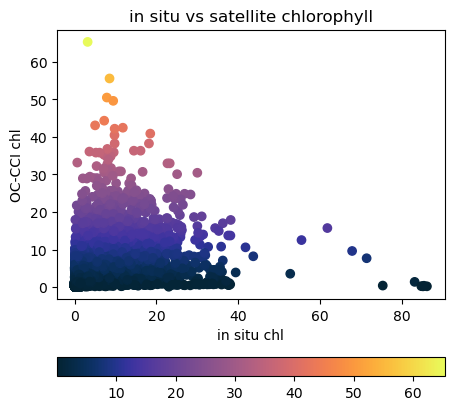

In [16]:
test =matched_all.dropna(subset=['chl_occci'])

fig=plt.figure(figsize=(5, 5))
axs1=fig.add_subplot(1,1,1)
im = axs1.scatter(test['chl'], test['chl_occci'], c=test['chl_occci'], cmap=cmo.thermal)
axs1.set_xlabel("in situ chl")
axs1.set_ylabel("OC-CCI chl")
axs1.set_title('in situ vs satellite chlorophyll')
cb=fig.colorbar(im,ax=axs1,orientation='horizontal')
#axs1.set_xlim([-1, 30])
#axs1.set_ylim([-1, 30])

In [75]:
chl_test=chl_all.loc[chl_all['depth']<=10].reset_index(drop=True)  #since OC-CCI is sattellite data and only records 1 depth, reduce to just surface waters 
chl_test = chl_test.tail(5).reset_index(drop=True) #subset dataframe to see if it works 
unique_dates=chl_test.copy()
unique_dates['date'] = unique_dates.datetime.dt.date #create column of just date
unique_dates = unique_dates.drop_duplicates(subset=['date'], keep='first').astype(str).reset_index(drop=True) #find all unique dates and turn to str
unique_dates['date'] = unique_dates['date'].str.replace('-', '') #take out all - 
dates = unique_dates.date

In [76]:
%%time
chl_test2 =insit_match(chl_test,dates)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 5 valid matches out of 5 points. Now extracting 3x3 grids...
0
1
2
3
4
Finished matching process!
CPU times: total: 141 ms
Wall time: 13.4 s
